# AI-Based Loan Approval and Credit Risk Analysis System

## Proje Amacı

Bu projede makine öğrenmesi kullanılarak bir müşterinin kredi başvurusunun onaylanıp onaylanmayacağı tahmin edilecektir.

Proje kapsamında:

- Veri Ön İşleme (Preprocessing)
- Keşifsel Veri Analizi (EDA)
- Sınıflandırma Modelleri
- Cross Validation
- Performans Metrikleri
- Confusion Matrix
- ROC Eğrisi
- Model Karşılaştırması
- Açıklanabilir Yapay Zeka (XAI)
- Streamlit Web Uygulaması

geliştirilecektir.

In [242]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Ön işleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Veri bölme ve doğrulama
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrikler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc

# Uyarıları kapat
import warnings
warnings.filterwarnings("ignore")

## Kütüphanelerin Yüklenmesi

Bu aşamada veri işleme, veri görselleştirme, makine öğrenmesi ve performans değerlendirme işlemlerinde kullanılacak Python kütüphaneleri projeye dahil edilmiştir.

In [243]:
# Load dataset
df = pd.read_csv("../data/loan_data.csv")

# Display first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Veri Setinin Yüklenmesi

Bu aşamada kredi başvuru verileri sisteme yüklenmiştir.

İlk 5 kayıt görüntülenerek veri setinin genel yapısı incelenmiştir.

In [244]:
print("Satır Sayısı :", df.shape[0])
print("Sütun Sayısı :", df.shape[1])

Satır Sayısı : 1228
Sütun Sayısı : 13


## Veri Seti Boyutunun İncelenmesi

Veri setindeki toplam gözlem ve değişken sayıları incelenmiştir.

Bu bilgiler veri setinin büyüklüğü hakkında bilgi vermektedir.

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1228 non-null   object 
 1   Gender             1202 non-null   object 
 2   Married            1222 non-null   object 
 3   Dependents         1198 non-null   object 
 4   Education          1228 non-null   object 
 5   Self_Employed      1164 non-null   object 
 6   ApplicantIncome    1228 non-null   int64  
 7   CoapplicantIncome  1228 non-null   float64
 8   LoanAmount         1184 non-null   float64
 9   Loan_Amount_Term   1200 non-null   float64
 10  Credit_History     1128 non-null   float64
 11  Property_Area      1228 non-null   object 
 12  Loan_Status        1228 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 124.8+ KB


## Veri Tiplerinin İncelenmesi

Bu aşamada değişkenlerin veri tipleri incelenmiştir.

Makine öğrenmesi modelleri sayısal verilerle çalıştığı için kategorik değişkenlerin dönüştürülmesi gerekecektir.

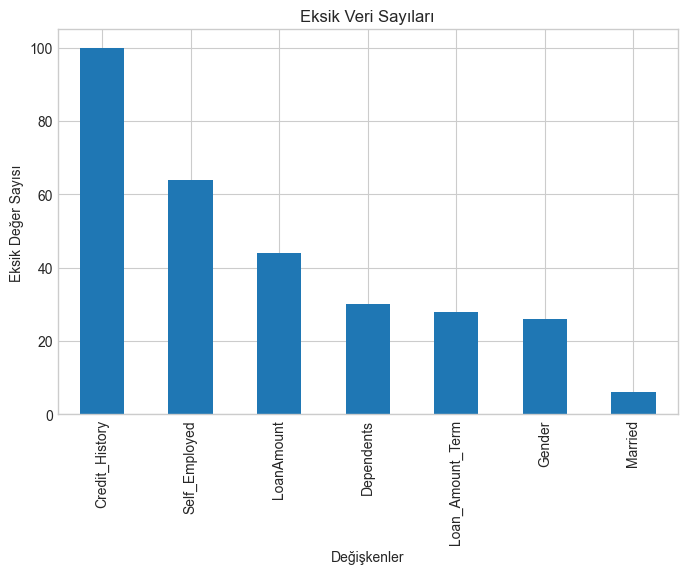

In [246]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Eksik Veri Sayıları")
plt.ylabel("Eksik Değer Sayısı")
plt.xlabel("Değişkenler")
plt.show()

## Eksik Veri Görselleştirmesi

Eksik değerlerin veri setindeki dağılımı görsel olarak incelenmiştir.

Bu sayede hangi sütunlarda eksik verilerin yoğunlaştığı tespit edilmiştir.

In [247]:
# Kategorik değişkenleri mod (en sık görülen değer) ile doldurma

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Sayısal değişkenleri ortalama ile doldurma

df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)

# Kredi süresi ve kredi geçmişi

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

## Eksik Verilerin Doldurulması

Veri setinde bulunan eksik değerler uygun yöntemler kullanılarak doldurulmuştur.

- Kategorik değişkenlerde en sık görülen değer (Mode) kullanılmıştır.
- Sayısal değişkenlerde ortalama değer (Mean) kullanılmıştır.

Bu işlem veri kaybını önlemek ve model performansını artırmak amacıyla yapılmıştır.

In [248]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [249]:
df.drop("Loan_ID", axis=1, inplace=True)

## Gereksiz Değişkenin Kaldırılması

Loan_ID sütunu her başvuru için benzersiz bir kimlik numarası içermektedir.

Bu sütun tahmin işlemi için anlamlı bilgi taşımadığından veri setinden çıkarılmıştır.


In [250]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,145.963682,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


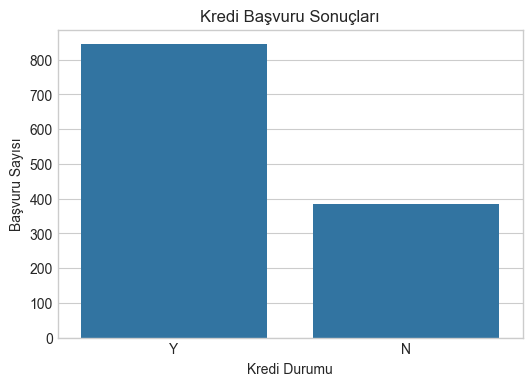

In [251]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Kredi Başvuru Sonuçları")
plt.xlabel("Kredi Durumu")
plt.ylabel("Başvuru Sayısı")

plt.show()

## Kredi Başvuru Sonuçlarının İncelenmesi

Bu grafik veri setindeki kredi başvurularının onaylanma ve reddedilme dağılımını göstermektedir.

Bu dağılım hedef değişkenin dengeli olup olmadığını incelemek için kullanılmıştır.

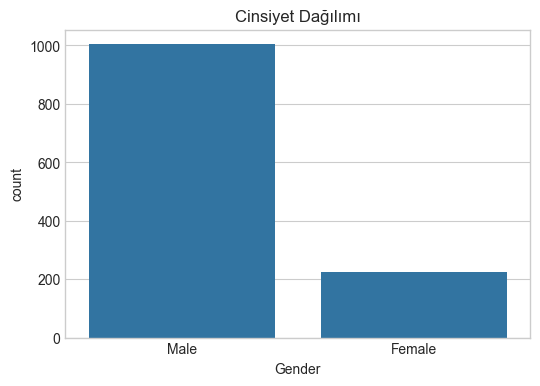

In [252]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Cinsiyet Dağılımı")

plt.show()

## Cinsiyet Dağılımı

Bu grafik başvuru sahiplerinin cinsiyet dağılımını göstermektedir.

Veri setindeki demografik yapı hakkında genel bilgi vermektedir.

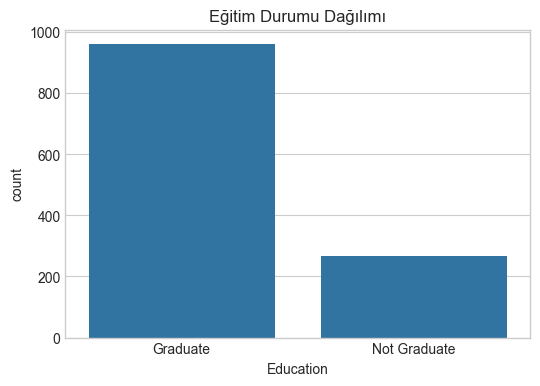

In [253]:
plt.figure(figsize=(6,4))

sns.countplot(x='Education', data=df)

plt.title("Eğitim Durumu Dağılımı")

plt.show()

## Eğitim Durumu Analizi

Başvuru sahiplerinin eğitim seviyeleri incelenmiştir.

Eğitim durumunun kredi onay sürecine etkisi daha sonraki analizlerde değerlendirilecektir.

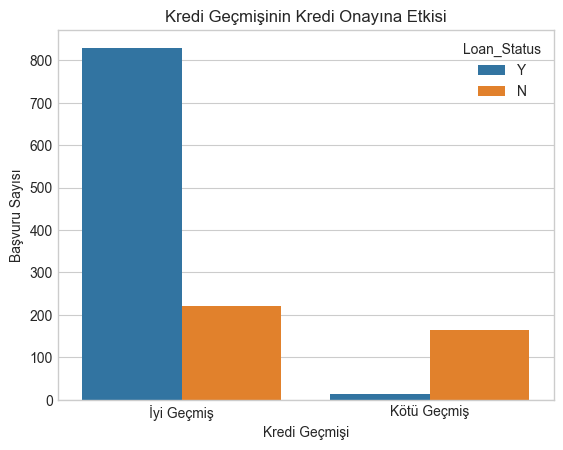

In [254]:
credit_history_labels = {
    0.0: "Kötü Geçmiş",
    1.0: "İyi Geçmiş"
}

temp_df = df.copy()

temp_df["Credit_History"] = temp_df["Credit_History"].map(
    credit_history_labels
)

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=temp_df
)

plt.title("Kredi Geçmişinin Kredi Onayına Etkisi")
plt.xlabel("Kredi Geçmişi")
plt.ylabel("Başvuru Sayısı")

plt.show()

## Kredi Geçmişinin Etkisi

Bu grafik kredi geçmişi ile kredi onayı arasındaki ilişkiyi göstermektedir.

Kredi geçmişinin kredi onayı üzerinde önemli bir etkisi olup olmadığı incelenmiştir.

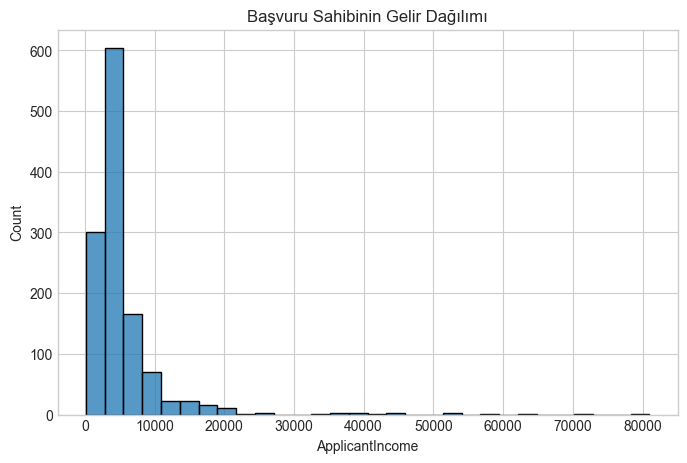

In [255]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'], bins=30)

plt.title("Başvuru Sahibinin Gelir Dağılımı")

plt.show()

## Gelir Dağılımı

Başvuru sahiplerinin gelir dağılımı incelenmiştir.

Bu analiz gelir değerlerinin dağılımını ve olası aykırı değerleri gözlemlemek amacıyla yapılmıştır.

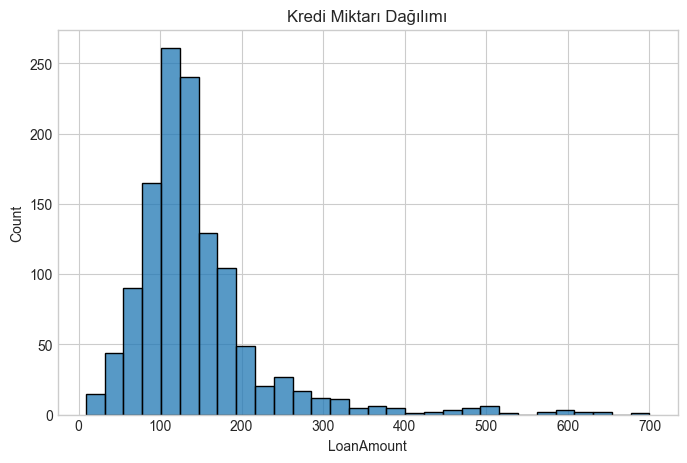

In [256]:
plt.figure(figsize=(8,5))

sns.histplot(df['LoanAmount'], bins=30)

plt.title("Kredi Miktarı Dağılımı")

plt.show()

## Kredi Miktarı Dağılımı

Talep edilen kredi miktarlarının dağılımı incelenmiştir.

Bu grafik kredi miktarlarının yoğunlaştığı aralıkları göstermektedir.

In [257]:
# Kategorik değişkenleri sayısala dönüştürme
encoders = {}

for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        encoders[column] = le

## Kategorik Verilerin Sayısallaştırılması

Makine öğrenmesi algoritmaları metinsel veriler ile çalışamadığı için kategorik değişkenler sayısal değerlere dönüştürülmüştür.

Bu işlem Label Encoding yöntemi kullanılarak gerçekleştirilmiştir.

In [258]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,145.963682,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


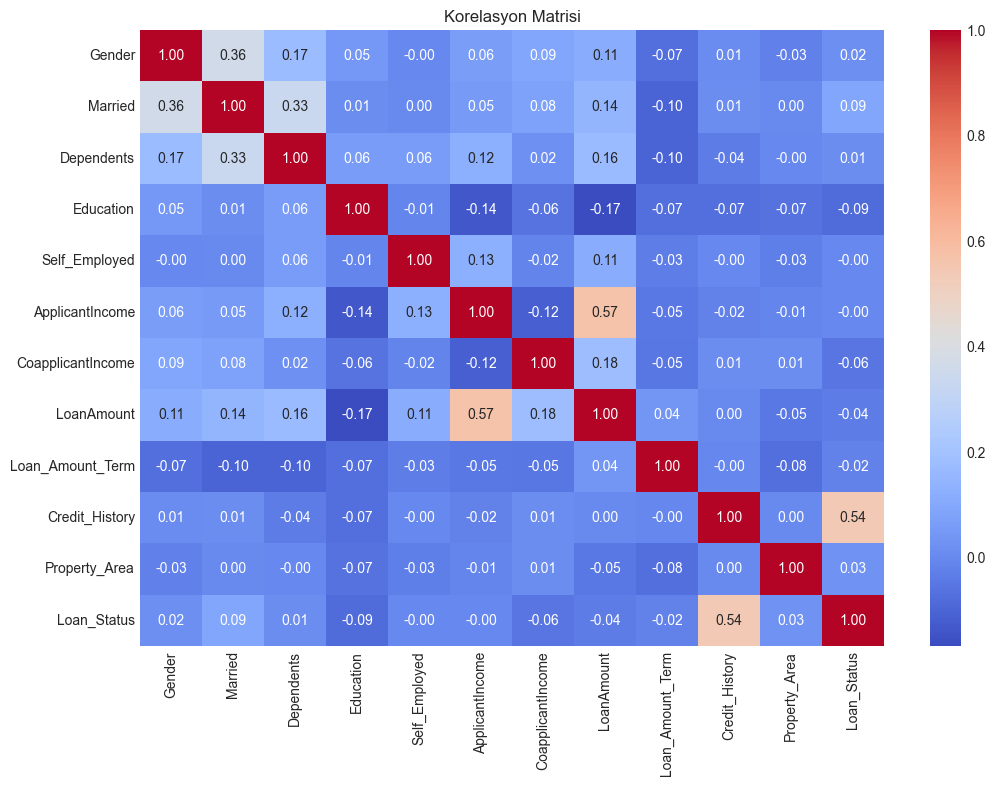

In [259]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Korelasyon Matrisi")

plt.show()

## Korelasyon Analizi

Değişkenler arasındaki ilişkiler korelasyon matrisi kullanılarak incelenmiştir.

Özellikle kredi onayı ile güçlü ilişkiye sahip değişkenler belirlenmeye çalışılmıştır.

In [260]:
# Özellikler (X)
X = df.drop("Loan_Status", axis=1)

# Hedef değişken (y)
y = df["Loan_Status"]

## Bağımlı ve Bağımsız Değişkenlerin Belirlenmesi

Bu aşamada hedef değişken (Loan_Status) veri setinden ayrılmıştır.

- X : Modelin kullanacağı özellikler
- y : Tahmin edilmek istenen hedef değişken

In [261]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Eğitim ve Test Verilerinin Oluşturulması

Veri seti:

- %80 Eğitim Verisi
- %20 Test Verisi

olarak ikiye ayrılmıştır.

Eğitim verisi modelin öğrenmesi için, test verisi ise performans değerlendirmesi için kullanılmıştır.

.

## Verilerin Ölçeklendirilmesi

In [262]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



Değişkenlerin farklı büyüklüklerde olması model performansını etkileyebileceği için StandardScaler kullanılarak veriler ölçeklendirilmiştir.


.

## LAZY ALGORİTMASI


In [263]:
from lazypredict.Supervised import LazyClassifier

lazy_model = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

models, predictions = lazy_model.fit(
    X_train,
    X_test,
    y_train,
    y_test
)

models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LabelSpreading,0.898374,0.884195,0.906168,0.898953,0.899831,0.898374,0.100228
LabelPropagation,0.894309,0.881305,0.911276,0.895100,0.896418,0.894309,0.067210
ExtraTreesClassifier,0.894309,0.853591,0.958271,0.891908,0.893145,0.894309,0.255387
ExtraTreeClassifier,0.813008,0.775992,0.775992,0.813008,0.813008,0.813008,0.017469
BaggingClassifier,0.821138,0.769895,0.868754,0.817975,0.816804,0.821138,0.067409
DecisionTreeClassifier,0.837398,0.769578,0.769578,0.829986,0.833874,0.837398,0.030498
RandomForestClassifier,0.845528,0.767440,0.928458,0.835344,0.846943,0.845528,0.382823
XGBClassifier,0.813008,0.728482,0.846940,0.800680,0.808440,0.813008,0.099173
KNeighborsClassifier,0.800813,0.715852,0.788028,0.788398,0.793677,0.800813,0.063649


Sınıf dönüşümü:
N -> 0
Y -> 1

LabelSpreading Sonuçları
------------------------------
Accuracy: 0.8170731707317073
Precision: 0.7924528301886793
Recall: 0.9940828402366864
F1 Score: 0.8818897637795275

Classification Report:
                precision    recall  f1-score   support

Reddedildi (N)       0.97      0.43      0.59        77
 Onaylandı (Y)       0.79      0.99      0.88       169

      accuracy                           0.82       246
     macro avg       0.88      0.71      0.74       246
  weighted avg       0.85      0.82      0.79       246



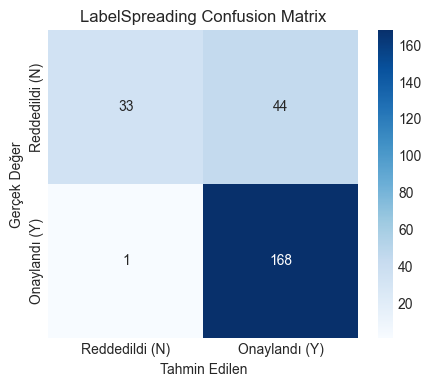

In [264]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LabelSpreading için veri kopyası
df_ls = df.copy()

# Eksik değer kontrolü
for col in df_ls.columns:
    if df_ls[col].dtype == "object":
        df_ls[col] = df_ls[col].fillna(df_ls[col].mode()[0])
    else:
        df_ls[col] = df_ls[col].fillna(df_ls[col].median())

# X ve y ayrımı
X_ls = df_ls.drop("Loan_Status", axis=1)
y_ls = df_ls["Loan_Status"]

# Hedef değişkeni sayısallaştırma
# N -> 0, Y -> 1
if y_ls.dtype == "object":
    y_ls_encoded = y_ls.map({
        "N": 0,
        "Y": 1
    })
else:
    y_ls_encoded = y_ls

y_ls_encoded = y_ls_encoded.astype(int)

print("Sınıf dönüşümü:")
print("N -> 0")
print("Y -> 1")

# Kategorik değişkenleri sayısallaştırma
X_ls = pd.get_dummies(X_ls, drop_first=True)

# Sonsuz değer kontrolü
X_ls = X_ls.replace([np.inf, -np.inf], np.nan)
X_ls = X_ls.fillna(0)

# Train-test ayrımı
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X_ls,
    y_ls_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_ls_encoded
)

# LabelSpreading modeli
label_spreading_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LabelSpreading(kernel="rbf", gamma=0.25, alpha=0.2))
])

# Model eğitimi
label_spreading_model.fit(X_train_ls, y_train_ls)

# Tahmin
y_pred_ls = label_spreading_model.predict(X_test_ls)

# Sonuçlar
print("\nLabelSpreading Sonuçları")
print("-" * 30)
print("Accuracy:", accuracy_score(y_test_ls, y_pred_ls))
print("Precision:", precision_score(y_test_ls, y_pred_ls, pos_label=1))
print("Recall:", recall_score(y_test_ls, y_pred_ls, pos_label=1))
print("F1 Score:", f1_score(y_test_ls, y_pred_ls, pos_label=1))

# Classification Report
sinif_isimleri = ["Reddedildi (N)", "Onaylandı (Y)"]

print("\nClassification Report:")
print(classification_report(
    y_test_ls,
    y_pred_ls,
    labels=[0, 1],
    target_names=sinif_isimleri
))

# Confusion Matrix
cm = confusion_matrix(
    y_test_ls,
    y_pred_ls,
    labels=[0, 1]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sinif_isimleri,
    yticklabels=sinif_isimleri
)

plt.title("LabelSpreading Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek Değer")

plt.show()

.


# Lojistik Regresyon Performansı

In [265]:
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [266]:
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
}

lr_df = pd.DataFrame(
    lr_metrics.items(),
    columns=["Metric", "Score"]
)

lr_df

,Metric,Score
0,Accuracy,0.796748
1,Precision,0.783410
2,Recall,0.982659
3,F1 Score,0.871795


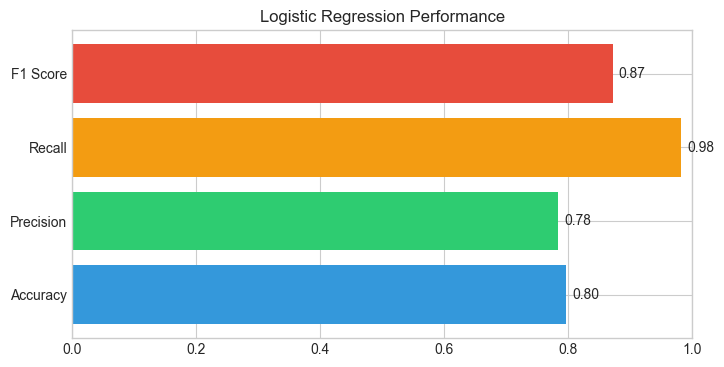

In [267]:
plt.figure(figsize=(8,4))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

bars = plt.barh(
    list(lr_metrics.keys()),
    list(lr_metrics.values()),
    color=colors
)

plt.xlim(0,1)
plt.title("Logistic Regression Performance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.show()


.

# Karar Ağacı Performansı

In [268]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [269]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.7926829268292683
Precision: 0.7961165048543689
Recall   : 0.9479768786127167
F1 Score : 0.8654353562005277


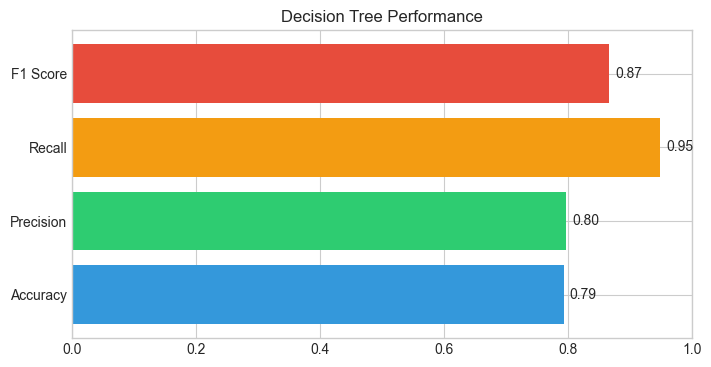

In [270]:
dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred)
}

plt.figure(figsize=(8,4))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

bars = plt.barh(
    list(dt_metrics.keys()),
    list(dt_metrics.values()),
    color=colors
)

plt.xlim(0,1)
plt.title("Decision Tree Performance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.show()

.


# Random Forest Performance

In [271]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.8455284552845529
Precision: 0.8426395939086294
Recall   : 0.9595375722543352
F1 Score : 0.8972972972972973


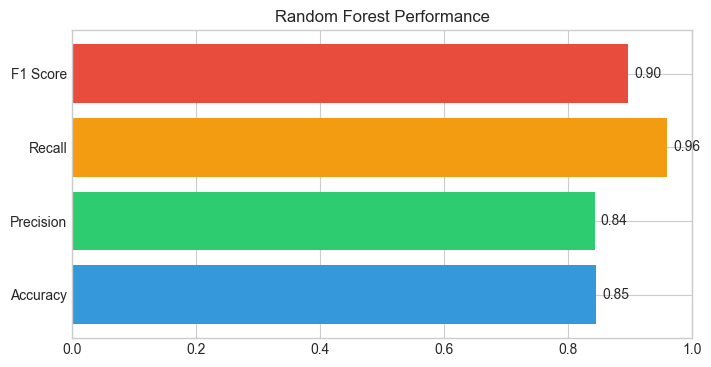

In [272]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred)
}

plt.figure(figsize=(8,4))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

bars = plt.barh(
    list(rf_metrics.keys()),
    list(rf_metrics.values()),
    color=colors
)

plt.xlim(0,1)
plt.title("Random Forest Performance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.show()

In [273]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results
models = results["Model"]



.
# Accuracy Comparison

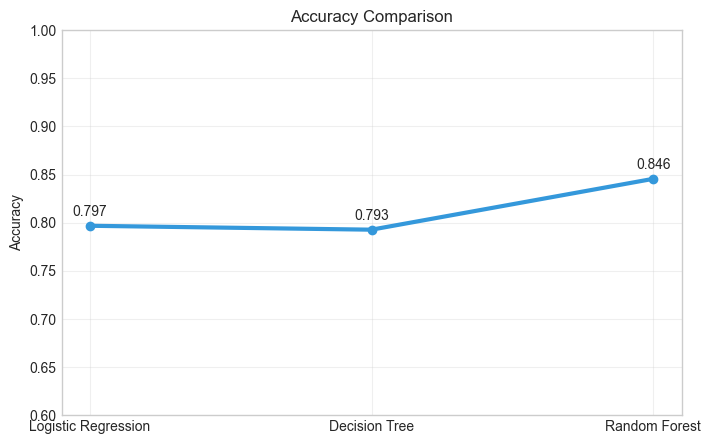

In [274]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["Accuracy"],
    marker='o',
    linewidth=3,
    color='#3498db'
)

for i, value in enumerate(results["Accuracy"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()



.
# Precision Comparison

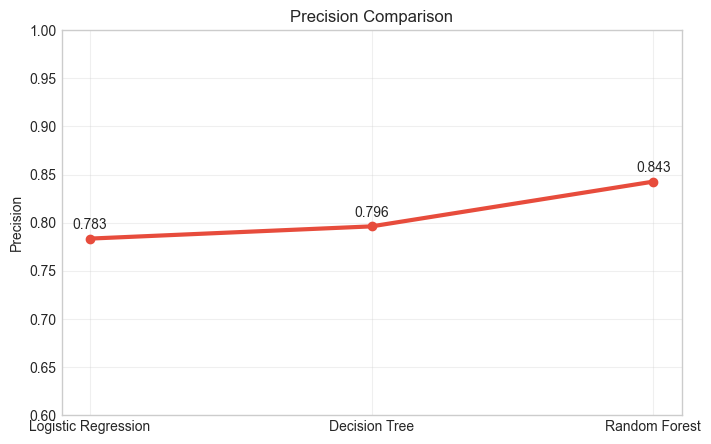

In [275]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["Precision"],
    marker='o',
    linewidth=3,
    color='#e74c3c'
)

for i, value in enumerate(results["Precision"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

.

# Recall Comparison

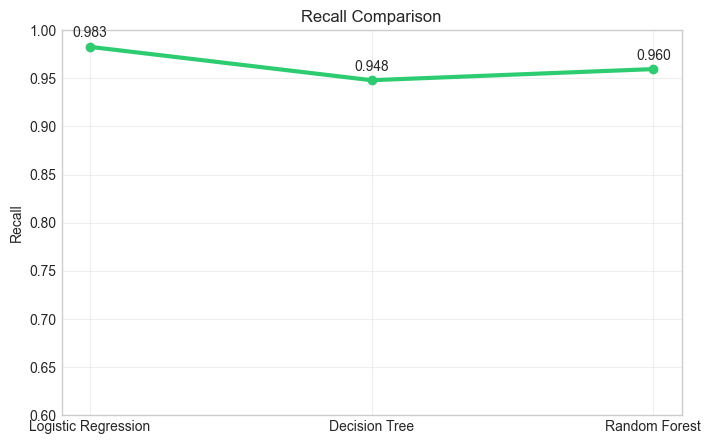

In [276]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["Recall"],
    marker='o',
    linewidth=3,
    color='#2ecc71'
)

for i, value in enumerate(results["Recall"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

.

# F1 Score Comparison

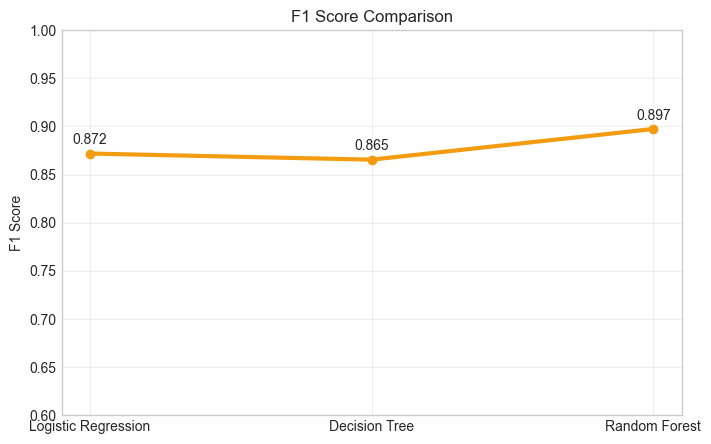

In [277]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["F1 Score"],
    marker='o',
    linewidth=3,
    color='#f39c12'
)

for i, value in enumerate(results["F1 Score"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

.

.
# Model Performance Comparison

In [278]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.796748,0.783410,0.982659,0.871795
1,Decision Tree,0.792683,0.796117,0.947977,0.865435
2,Random Forest,0.845528,0.842640,0.959538,0.897297


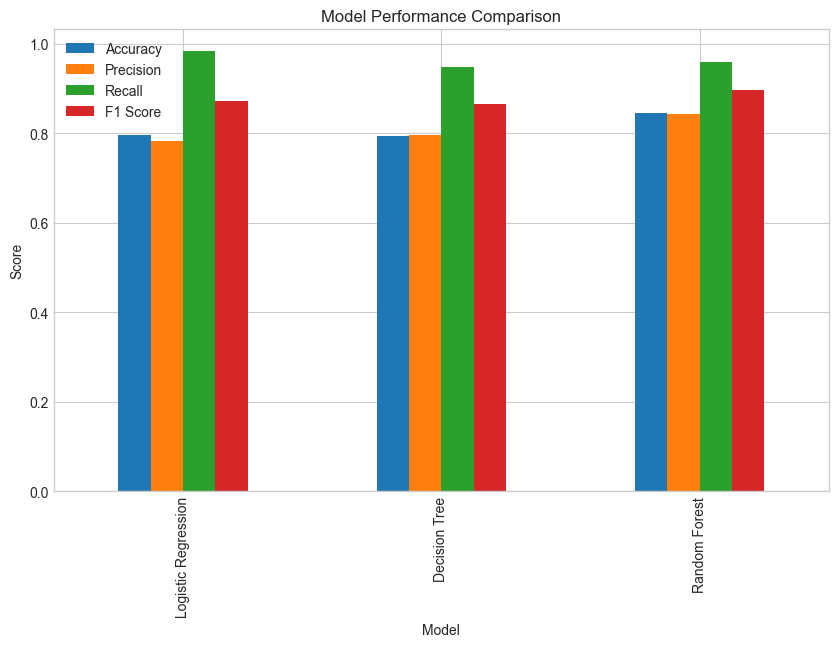

In [279]:
metrics_df = results.set_index("Model")

metrics_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.show()

## Modellerin Karşılaştırılması

Bu grafik Logistic Regression, Decision Tree ve Random Forest algoritmalarının doğruluk oranlarını karşılaştırmaktadır.

En yüksek doğruluğa sahip model proje kapsamında en başarılı model olarak değerlendirilmiştir.

.

## Overfitting Test

In [280]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Eğitim-test ayrımı
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic Regression için ölçekleme
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# F1 Score fonksiyonu
# y değerlerin 0-1 ise direkt çalışır, Y-N ise Y pozitif sınıf kabul edilir
def calculate_f1(y_true, y_pred):
    unique_values = set(pd.Series(y_true).unique())

    if "Y" in unique_values:
        return f1_score(y_true, y_pred, pos_label="Y")
    else:
        return f1_score(y_true, y_pred)

# Overfitting durumunu yorumlama fonksiyonu
def overfitting_status(acc_diff, f1_diff):
    if acc_diff >= 0.10 or f1_diff >= 0.10:
        return "Overfitting Riski Yüksek"
    elif acc_diff >= 0.04 or f1_diff >= 0.03:
        return "Hafif Overfitting Eğilimi"
    else:
        return "Dengeli"

# Modeller
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# İlk Random Forest: bilerek serbest bırakıldı
# Burada modelin ezber yapıp yapmadığı görülecek
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Modelleri eğitiyoruz
lr_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

overfitting_results = []

for name, model in models.items():

    if name == "Logistic Regression":
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
    else:
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)


    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_f1 = calculate_f1(y_train, train_pred)
    test_f1 = calculate_f1(y_test, test_pred)

    acc_diff = abs(train_acc - test_acc)
    f1_diff = abs(train_f1 - test_f1)

    overfitting_results.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Accuracy Difference": round(acc_diff, 4),
        "Train F1": round(train_f1, 4),
        "Test F1": round(test_f1, 4),
        "F1 Difference": round(f1_diff, 4),
        "Overfitting Durumu": overfitting_status(acc_diff, f1_diff)
    })

overfitting_df = pd.DataFrame(overfitting_results)

overfitting_df

,Model,Train Accuracy,Test Accuracy,Accuracy Difference,Train F1,Test F1,F1 Difference,Overfitting Durumu
0,Logistic Regression,0.8116,0.8171,0.0055,0.8774,0.8819,0.0045,Dengeli
1,Decision Tree,0.8167,0.8089,0.0078,0.8806,0.8760,0.0046,Dengeli
2,Random Forest,1.0000,0.8943,0.1057,1.0000,0.9278,0.0722,Overfitting Riski Yüksek


.



## Hiperparametre ayarı

In [281]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# F1 hesaplama fonksiyonu
# Eğer hedef değişken Y/N ise Y pozitif sınıf kabul edilir
def calculate_f1(y_true, y_pred):
    unique_values = set(pd.Series(y_true).unique())

    if "Y" in unique_values:
        return f1_score(y_true, y_pred, pos_label="Y", zero_division=0)
    else:
        return f1_score(y_true, y_pred, zero_division=0)

# Overfitting durumunu yorumlama fonksiyonu
def overfitting_status(acc_diff, f1_diff):
    if acc_diff >= 0.10 or f1_diff >= 0.10:
        return "Overfitting Riski Yüksek"
    elif acc_diff >= 0.04 or f1_diff >= 0.03:
        return "Hafif Overfitting Eğilimi"
    else:
        return "Dengeli"

# ---------------------------------------------------------
# 1. İlk Random Forest modeli
# ---------------------------------------------------------
rf_first_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_first_model.fit(X_train, y_train)

# İlk Random Forest tahminleri
rf_first_train_pred = rf_first_model.predict(X_train)
rf_first_test_pred = rf_first_model.predict(X_test)

# İlk Random Forest metrikleri
rf_first_train_acc = accuracy_score(y_train, rf_first_train_pred)
rf_first_test_acc = accuracy_score(y_test, rf_first_test_pred)

rf_first_train_f1 = calculate_f1(y_train, rf_first_train_pred)
rf_first_test_f1 = calculate_f1(y_test, rf_first_test_pred)

# ---------------------------------------------------------
# 2. Overfitting azaltılmış Random Forest modeli
# ---------------------------------------------------------
rf_tuned_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_tuned_model.fit(X_train, y_train)

# Düzenlenmiş Random Forest tahminleri
rf_tuned_train_pred = rf_tuned_model.predict(X_train)
rf_tuned_test_pred = rf_tuned_model.predict(X_test)

# Düzenlenmiş Random Forest metrikleri
rf_tuned_train_acc = accuracy_score(y_train, rf_tuned_train_pred)
rf_tuned_test_acc = accuracy_score(y_test, rf_tuned_test_pred)

rf_tuned_train_f1 = calculate_f1(y_train, rf_tuned_train_pred)
rf_tuned_test_f1 = calculate_f1(y_test, rf_tuned_test_pred)

# ---------------------------------------------------------
# 3. Karşılaştırma tablosu
# ---------------------------------------------------------
rf_comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest - İlk Hali",
        "Random Forest - Overfitting Azaltılmış"
    ],

    "Yapılan İşlem": [
        "Varsayılan model kullanıldı",
        "Hiperparametre ayarı yapıldı"
    ],

    "Train Accuracy": [
        round(rf_first_train_acc, 4),
        round(rf_tuned_train_acc, 4)
    ],

    "Test Accuracy": [
        round(rf_first_test_acc, 4),
        round(rf_tuned_test_acc, 4)
    ],

    "Accuracy Difference": [
        round(abs(rf_first_train_acc - rf_first_test_acc), 4),
        round(abs(rf_tuned_train_acc - rf_tuned_test_acc), 4)
    ],

    "Train F1": [
        round(rf_first_train_f1, 4),
        round(rf_tuned_train_f1, 4)
    ],

    "Test F1": [
        round(rf_first_test_f1, 4),
        round(rf_tuned_test_f1, 4)
    ],

    "F1 Difference": [
        round(abs(rf_first_train_f1 - rf_first_test_f1), 4),
        round(abs(rf_tuned_train_f1 - rf_tuned_test_f1), 4)
    ]
})

rf_comparison_df["Overfitting Durumu"] = rf_comparison_df.apply(
    lambda row: overfitting_status(
        row["Accuracy Difference"],
        row["F1 Difference"]
    ),
    axis=1
)

# ---------------------------------------------------------
# 4. Bundan sonraki hücrelerde ayarlı Random Forest kullanılsın
# ---------------------------------------------------------
rf_original_model = rf_first_model

rf_model = rf_tuned_model

rf_train_pred = rf_tuned_train_pred
rf_test_pred = rf_tuned_test_pred

rf_train_acc = rf_tuned_train_acc
rf_test_acc = rf_tuned_test_acc

rf_train_f1 = rf_tuned_train_f1
rf_test_f1 = rf_tuned_test_f1

rf_comparison_df

,Model,Yapılan İşlem,Train Accuracy,Test Accuracy,Accuracy Difference,Train F1,Test F1,F1 Difference,Overfitting Durumu
0,Random Forest - İlk Hali,Varsayılan model kullanıldı,1.0000,0.8943,0.1057,1.000,0.9278,0.0722,Overfitting Riski Yüksek
1,Random Forest - Overfitting Azaltılmış,Hiperparametre ayarı yapıldı,0.8452,0.8211,0.0241,0.894,0.8824,0.0116,Dengeli


.

.

.

## Cross Validation 

In [282]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(),
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.78455285 0.82113821 0.82520325 0.7755102  0.84081633]

Average Accuracy:
0.8094441679110668


## Cross Validation

Model performansının daha güvenilir şekilde ölçülebilmesi için 5 katlı Cross Validation uygulanmıştır.

Veri seti 5 parçaya ayrılmıştır.

Her seferinde:
- 4 parça eğitim
- 1 parça test

olarak kullanılmıştır.

Bu işlem 5 kez tekrar edilerek modelin genelleme başarısı ölçülmüştür.

In [283]:
# ============================================================
# 5-Fold Stratified Cross Validation
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# 1. Veri setini oku
# ------------------------------------------------------------

possible_paths = [
    "loan_data_lp_ids.csv",
    "loan_data.csv",
    "data/loan_data_lp_ids.csv",
    "data/loan_data.csv",
    "../data/loan_data_lp_ids.csv",
    "../data/loan_data.csv"
]

data_path = None

for path in possible_paths:
    if Path(path).exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Veri seti bulunamadı. loan_data.csv veya loan_data_lp_ids.csv dosyasının yolunu kontrol et."
    )

df = pd.read_csv(data_path)

print("Kullanılan veri seti:", data_path)


# ------------------------------------------------------------
# 2. Sütun isimlerini Türkçeye çevir
# Eğer zaten Türkçeyse sorun çıkarmaz
# ------------------------------------------------------------

df.rename(columns={
    "Loan_ID": "Basvuru_ID",
    "Gender": "Cinsiyet",
    "Married": "Evli",
    "Dependents": "Bakmakla_Yukumlu_Kisi_Sayisi",
    "Education": "Egitim_Durumu",
    "Self_Employed": "Serbest_Calisan",
    "ApplicantIncome": "Basvuran_Geliri",
    "CoapplicantIncome": "Ek_Basvuran_Geliri",
    "LoanAmount": "Kredi_Tutari",
    "Loan_Amount_Term": "Kredi_Vadesi",
    "Credit_History": "Kredi_Gecmisi",
    "Property_Area": "Mulk_Bolgesi",
    "Loan_Status": "Kredi_Durumu"
}, inplace=True)


# ------------------------------------------------------------
# 3. X ve y oluştur
# ------------------------------------------------------------

X = df.drop(["Basvuru_ID", "Kredi_Durumu"], axis=1)
y = df["Kredi_Durumu"]

# Hedef değişkeni sayısallaştır
# N -> 0, Y -> 1
if y.dtype == "object":
    y = y.map({
        "N": 0,
        "Y": 1
    })

y = y.astype(int)


# ------------------------------------------------------------
# 4. Eksik değerleri doldur
# ------------------------------------------------------------

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())


# ------------------------------------------------------------
# 5. Kategorik değişkenleri sayısala çevir
# ------------------------------------------------------------

X = pd.get_dummies(X, drop_first=True)

print("X şekli:", X.shape)
print("y şekli:", y.shape)
print("Sınıf dağılımı:")
print(y.value_counts())


# ------------------------------------------------------------
# 6. 5-Fold Stratified Cross Validation ayarı
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 7. Modeller
# Random Forest burada hiperparametre ayarı yapılmış halidir
# ------------------------------------------------------------

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    )
}


# ------------------------------------------------------------
# 8. Cross Validation sonuçları
# ------------------------------------------------------------

cv_results = []

for model_name, model in models.items():

    accuracy_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    f1_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": model_name,
        "CV Ortalama Accuracy": round(accuracy_scores.mean(), 4),
        "CV Accuracy Standart Sapma": round(accuracy_scores.std(), 4),
        "CV Ortalama F1": round(f1_scores.mean(), 4),
        "CV F1 Standart Sapma": round(f1_scores.std(), 4)
    })

cv_df = pd.DataFrame(cv_results)

cv_df

Kullanılan veri seti: ../data/loan_data.csv
X şekli: (1228, 14)
y şekli: (1228,)
Sınıf dağılımı:
Kredi_Durumu
1    844
0    384
Name: count, dtype: int64


,Model,CV Ortalama Accuracy,CV Accuracy Standart Sapma,CV Ortalama F1,CV F1 Standart Sapma
0,Logistic Regression,0.8111,0.0168,0.8772,0.0098
1,Decision Tree,0.8062,0.0169,0.8738,0.0105
2,Random Forest,0.7972,0.0178,0.8632,0.0128


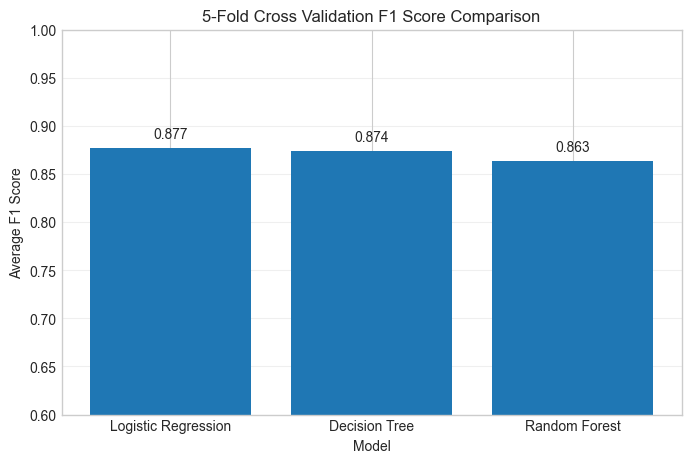

In [284]:
# ============================================================
# Cross Validation F1 Score Grafiği
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    cv_df["Model"],
    cv_df["CV Ortalama F1"]
)

plt.title("5-Fold Cross Validation F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("Average F1 Score")
plt.ylim(0.6, 1)

for i, score in enumerate(cv_df["CV Ortalama F1"]):
    plt.text(
        i,
        score + 0.01,
        f"{score:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

.


# Confusion Matrix


In [285]:
lr_pred_for_cm = lr_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, lr_pred_for_cm)
cm

array([[ 33,  44],
       [  1, 168]])

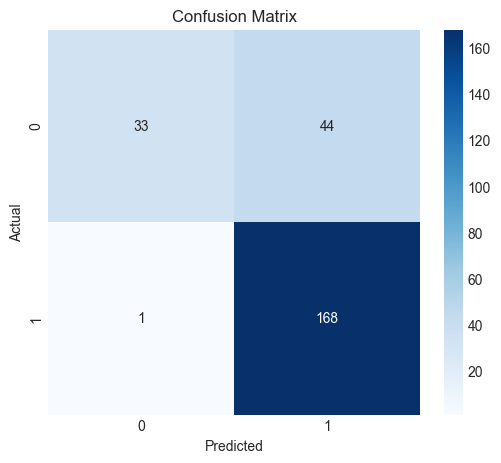

In [286]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Confusion Matrix

Confusion Matrix modeli daha detaylı değerlendirmek amacıyla oluşturulmuştur.

Bu matris:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

değerlerini göstermektedir.

Bu sayede modelin hangi sınıflarda hata yaptığı incelenebilmektedir.

.

.


.




## MODEL PERFORMANS ANALİZİ - ROC EĞRİSİ  & AUC

In [287]:
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

.

.
## 1.Logistic Regression ROC Curve

In [288]:
from sklearn.metrics import roc_curve, auc

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

lr_auc = auc(lr_fpr, lr_tpr)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.7563206024744487


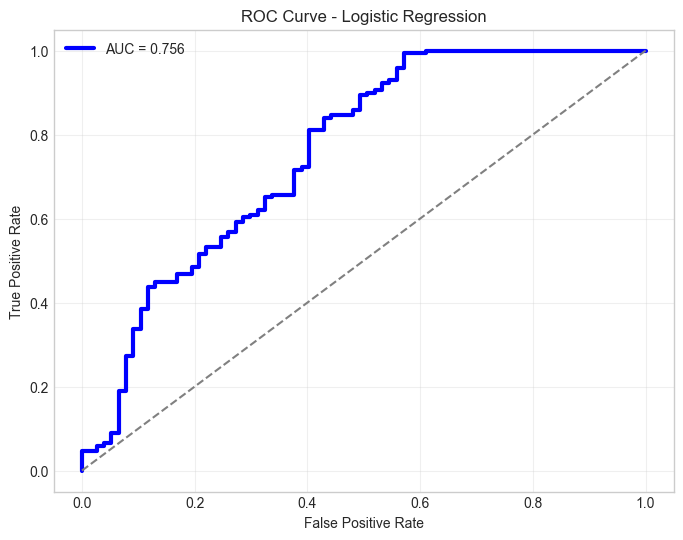

In [289]:
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=3,
    label=f"AUC = {lr_auc:.3f}",
    color="blue"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Logistic Regression ROC Curve

Bu grafik Logistic Regression modelinin kredi onayı ve kredi reddi sınıflarını ayırt etme başarısını göstermektedir.

AUC değeri model performansını özetlemektedir. AUC değerinin 1'e yaklaşması model başarısının arttığını göstermektedir.

.

.



## 2.Decision Tree ROC Curve

In [290]:
dt_prob = dt_model.predict_proba(X_test)[:,1]

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

dt_auc = auc(dt_fpr, dt_tpr)

print("Decision Tree AUC:", dt_auc)

Decision Tree AUC: 0.7853684776761699


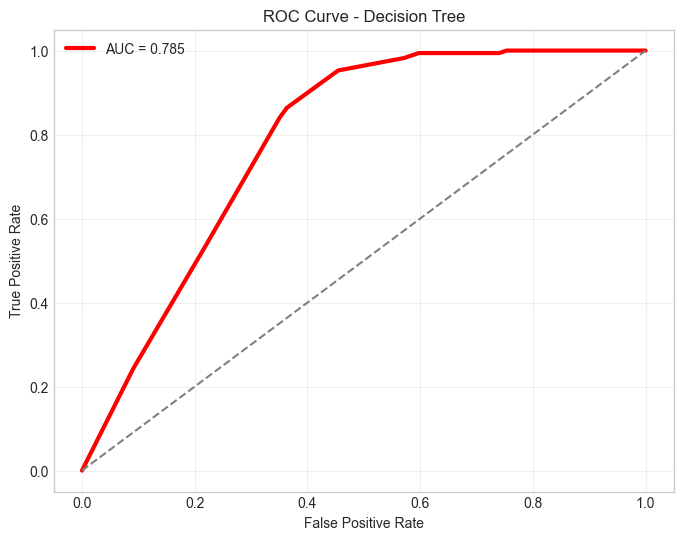

In [291]:
plt.figure(figsize=(8,6))

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=3,
    label=f"AUC = {dt_auc:.3f}",
    color="red"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Decision Tree ROC Curve

Bu grafik Decision Tree modelinin sınıflandırma performansını göstermektedir.

Elde edilen AUC değeri modelin kredi onayı ve kredi reddi sınıflarını ayırt etme başarısını ifade etmektedir.

.

.

## 3.Random Forest ROC Curve

In [292]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

rf_auc = auc(rf_fpr, rf_tpr)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.8201029739491278


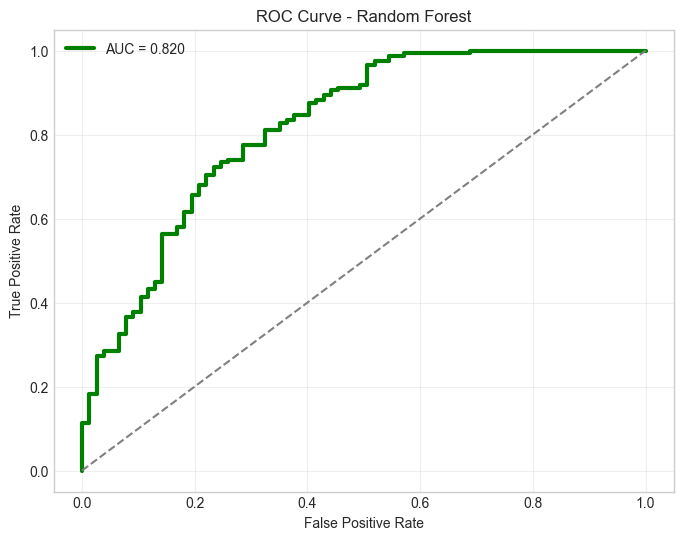

In [293]:
plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=3,
    label=f"AUC = {rf_auc:.3f}",
    color="green"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Random Forest ROC Curve

Bu grafik Random Forest modelinin ROC performansını göstermektedir.

AUC değeri modelin sınıfları ayırt etme başarısını ölçmektedir.

.

.

## ROC Curve Comparison

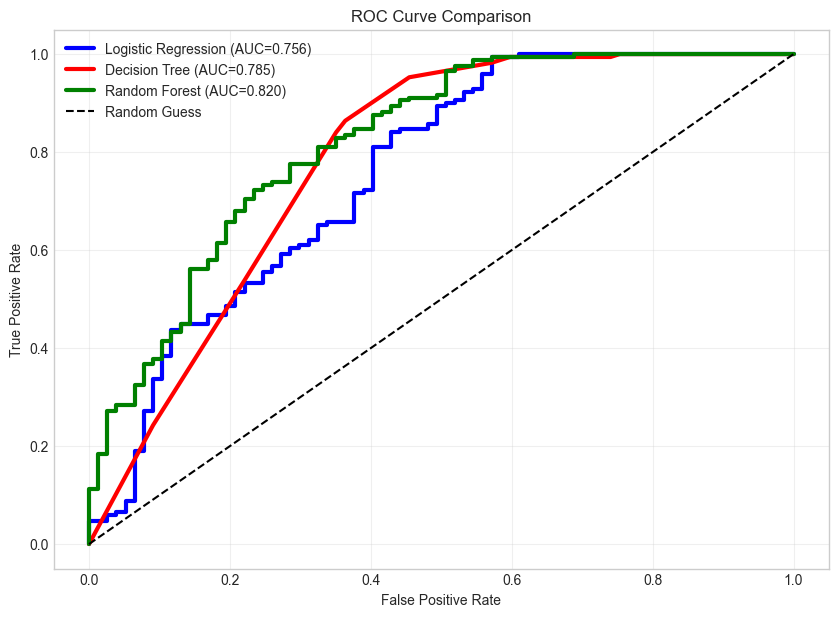

In [294]:
plt.figure(figsize=(10,7))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=3,
    label=f"Logistic Regression (AUC={lr_auc:.3f})",
    color="blue"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=3,
    label=f"Decision Tree (AUC={dt_auc:.3f})",
    color="red"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=3,
    label=f"Random Forest (AUC={rf_auc:.3f})",
    color="green"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Guess"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [295]:
auc_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "AUC":[
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

auc_results

,Model,AUC
0,Logistic Regression,0.756321
1,Decision Tree,0.785368
2,Random Forest,0.820103


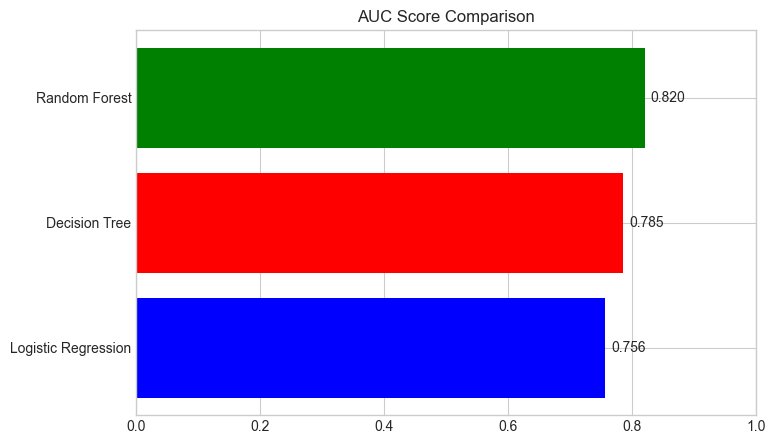

In [296]:
plt.figure(figsize=(8,5))

colors = ["blue","red","green"]

bars = plt.barh(
    auc_results["Model"],
    auc_results["AUC"],
    color=colors
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.01,
        bar.get_y()+bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.title("AUC Score Comparison")
plt.xlim(0,1)

plt.show()

# Yapay zeka 


In [297]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
})

feature_importance

,Feature,Coefficient
0,Gender,-0.063733
1,Married,0.281818
2,Dependents,0.020260
3,Education,-0.179555
4,Self_Employed,-0.025576
5,ApplicantIncome,0.032686
6,CoapplicantIncome,-0.149290
7,LoanAmount,-0.139730
8,Loan_Amount_Term,-0.083352
9,Credit_History,1.307308


.

.

## 3. Logistic Regression Explainable AI

In [298]:
feature_importance["Abs_Coefficient"] = abs(
    feature_importance["Coefficient"]
)

feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Abs_Coefficient
9,Credit_History,1.307308,1.307308
1,Married,0.281818,0.281818
3,Education,-0.179555,0.179555
6,CoapplicantIncome,-0.149290,0.149290
7,LoanAmount,-0.139730,0.139730
8,Loan_Amount_Term,-0.083352,0.083352
0,Gender,-0.063733,0.063733
10,Property_Area,0.046086,0.046086
5,ApplicantIncome,0.032686,0.032686
4,Self_Employed,-0.025576,0.025576


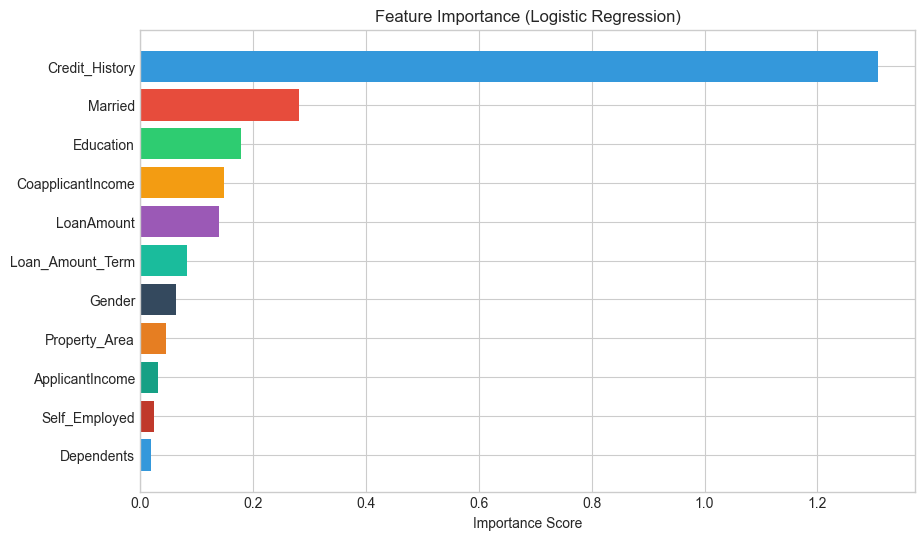

In [299]:
plt.figure(figsize=(10,6))

colors = [
    "#3498db",
    "#e74c3c",
    "#2ecc71",
    "#f39c12",
    "#9b59b6",
    "#1abc9c",
    "#34495e",
    "#e67e22",
    "#16a085",
    "#c0392b"
]

plt.barh(
    feature_importance["Feature"],
    feature_importance["Abs_Coefficient"],
    color=colors[:len(feature_importance)]
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

.

## 1. Decision Tree Explainable AI

In [300]:
dt_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance

,Feature,Importance
9,Credit_History,0.813914
7,LoanAmount,0.071837
5,ApplicantIncome,0.036845
10,Property_Area,0.029951
3,Education,0.021422
1,Married,0.020879
6,CoapplicantIncome,0.004117
8,Loan_Amount_Term,0.001035
0,Gender,0.000000
2,Dependents,0.000000


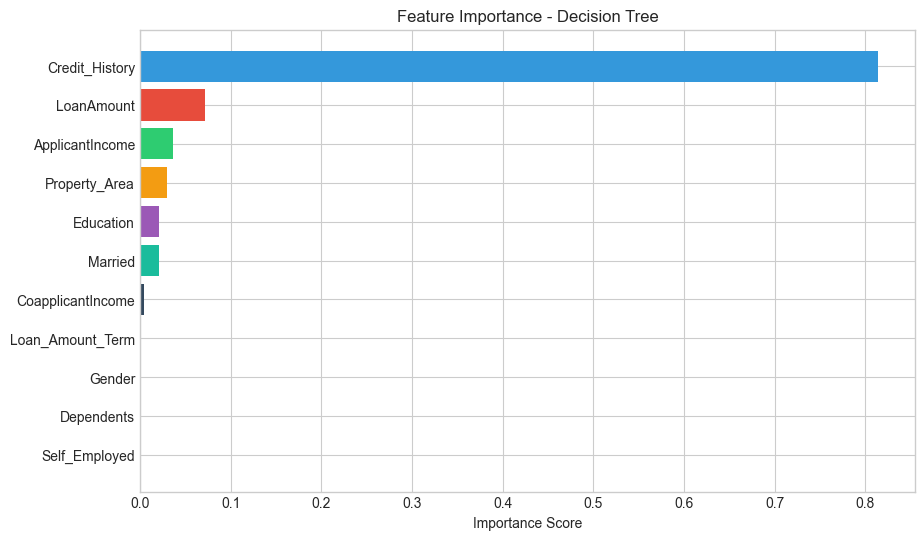

In [301]:
plt.figure(figsize=(10,6))

colors = [
    "#3498db","#e74c3c","#2ecc71","#f39c12",
    "#9b59b6","#1abc9c","#34495e","#e67e22",
    "#16a085","#c0392b","#7f8c8d"
]

plt.barh(
    dt_importance["Feature"],
    dt_importance["Importance"],
    color=colors[:len(dt_importance)]
)

plt.title("Feature Importance - Decision Tree")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

.

## 2. Random Forest Explainable AI

In [302]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
9,Credit_History,0.544225
7,LoanAmount,0.119726
5,ApplicantIncome,0.095502
6,CoapplicantIncome,0.071800
10,Property_Area,0.057271
1,Married,0.027294
2,Dependents,0.026053
8,Loan_Amount_Term,0.022117
3,Education,0.021320
4,Self_Employed,0.008235


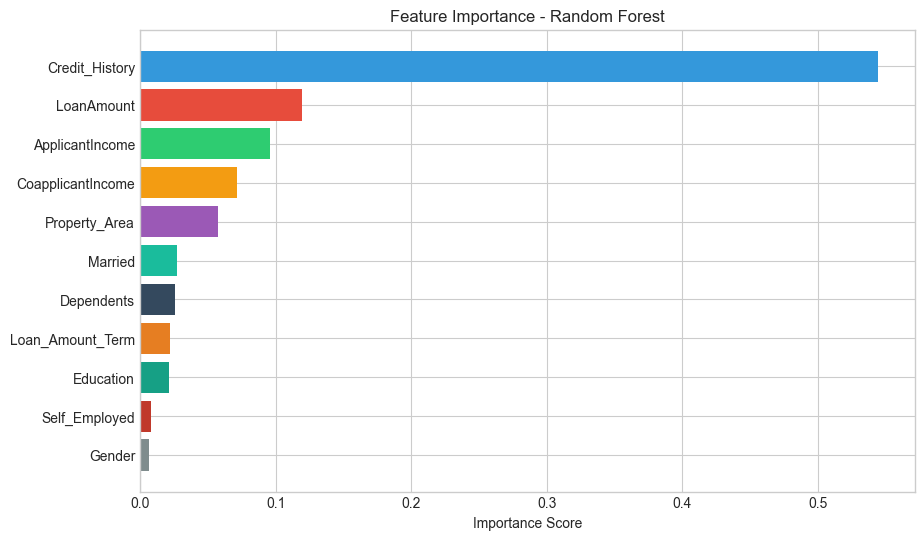

In [303]:
plt.figure(figsize=(10,6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"],
    color=colors[:len(rf_importance)]
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

.

### Karşılaştırma Tablosu

In [304]:
comparison_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Logistic Regression": abs(lr_model.coef_[0]),
    "Decision Tree": dt_model.feature_importances_,
    "Random Forest": rf_model.feature_importances_
})

comparison_importance

,Feature,Logistic Regression,Decision Tree,Random Forest
0,Gender,0.063733,0.000000,0.006457
1,Married,0.281818,0.020879,0.027294
2,Dependents,0.020260,0.000000,0.026053
3,Education,0.179555,0.021422,0.021320
4,Self_Employed,0.025576,0.000000,0.008235
5,ApplicantIncome,0.032686,0.036845,0.095502
6,CoapplicantIncome,0.149290,0.004117,0.071800
7,LoanAmount,0.139730,0.071837,0.119726
8,Loan_Amount_Term,0.083352,0.001035,0.022117
9,Credit_History,1.307308,0.813914,0.544225


.

.

### Top 5 Özelliği Karşılaştırma

In [305]:
comparison_importance["Average"] = (
    comparison_importance["Logistic Regression"] +
    comparison_importance["Decision Tree"] +
    comparison_importance["Random Forest"]
) / 3

top_features = comparison_importance.sort_values(
    by="Average",
    ascending=False
).head(5)

top_features

,Feature,Logistic Regression,Decision Tree,Random Forest,Average
9,Credit_History,1.307308,0.813914,0.544225,0.888482
7,LoanAmount,0.139730,0.071837,0.119726,0.110431
1,Married,0.281818,0.020879,0.027294,0.109997
6,CoapplicantIncome,0.149290,0.004117,0.071800,0.075069
3,Education,0.179555,0.021422,0.021320,0.074099


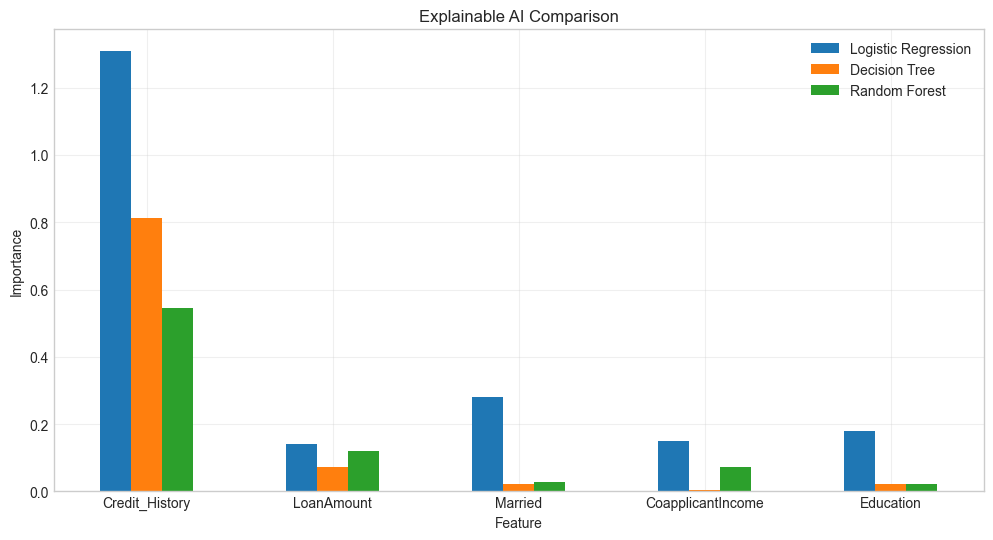

In [306]:
top_features_plot = top_features.set_index("Feature")

top_features_plot[
    [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Explainable AI Comparison")

plt.ylabel("Importance")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

.

.

## LIME

In [307]:
# ============================================================
# LIME Açıklanabilir Yapay Zeka Analizi
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# 1. X_train / X_test yoksa oluştur
# ------------------------------------------------------------

try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )


# ------------------------------------------------------------
# 2. LIME için kullanılacak modeli seç
# Öncelik: ayarlanmış Random Forest
# ------------------------------------------------------------

try:
    lime_model = rf_tuned_model
except NameError:
    try:
        lime_model = rf_model
    except NameError:
        lime_model = RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42
        )


# Model eğitilmemişse eğit
try:
    lime_model.predict_proba(X_test)
except:
    lime_model.fit(X_train, y_train)


# ------------------------------------------------------------
# 3. LIME için veri hazırlığı
# ------------------------------------------------------------

X_train_lime_full = pd.DataFrame(X_train).copy()
X_test_lime_full = pd.DataFrame(X_test).copy()

# Sütun isimleri yoksa oluştur
if X_train_lime_full.columns.dtype == "int64":
    X_train_lime_full.columns = [f"Feature_{i}" for i in range(X_train_lime_full.shape[1])]
    X_test_lime_full.columns = X_train_lime_full.columns

# Sayısal forma çevir
X_train_lime_full = X_train_lime_full.apply(pd.to_numeric, errors="coerce")
X_test_lime_full = X_test_lime_full.apply(pd.to_numeric, errors="coerce")

# Sonsuz değerleri temizle
X_train_lime_full = X_train_lime_full.replace([np.inf, -np.inf], np.nan)
X_test_lime_full = X_test_lime_full.replace([np.inf, -np.inf], np.nan)

# Eksik değerleri medyan ile doldur
X_train_lime_full = X_train_lime_full.fillna(X_train_lime_full.median())
X_test_lime_full = X_test_lime_full.fillna(X_train_lime_full.median())

# Sabit sütunları LIME için çıkar
lime_cols = X_train_lime_full.columns[X_train_lime_full.nunique() > 1].tolist()

X_train_lime = X_train_lime_full[lime_cols]
X_test_lime = X_test_lime_full[lime_cols]

# Sabit sütunları geri eklemek için temel satır
base_row = X_train_lime_full.iloc[0].copy()


# ------------------------------------------------------------
# 4. LIME tahmin fonksiyonu
# LIME eksik sütun gönderdiği için tam X formatına geri çeviriyoruz
# ------------------------------------------------------------

def lime_predict_fn(data):
    data_df = pd.DataFrame(data, columns=lime_cols)

    full_df = pd.DataFrame(
        np.tile(base_row.values, (data_df.shape[0], 1)),
        columns=X_train_lime_full.columns
    )

    full_df[lime_cols] = data_df.values

    return lime_model.predict_proba(full_df)


# ------------------------------------------------------------
# 5. LIME açıklayıcı oluştur
# ------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=lime_cols,
    class_names=["Kredi Reddedildi", "Kredi Onaylandı"],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)


# ------------------------------------------------------------
# 6. Test verisinden bir başvuru seç
# ------------------------------------------------------------

i = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[i].values,
    predict_fn=lime_predict_fn,
    num_features=10
)


# ------------------------------------------------------------
# 7. LIME sonucunu tablo olarak göster
# ------------------------------------------------------------

lime_result_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Özellik", "Etki Değeri"]
)

lime_result_df

,Özellik,Etki Değeri
0,Credit_History,0.096584
1,LoanAmount,-0.037366
2,Married,0.020961
3,Property_Area,0.014805
4,Education,-0.014451
5,Loan_Amount_Term,-0.014187
6,ApplicantIncome,0.010435
7,Dependents,0.005514
8,Gender,0.000513
9,Self_Employed,0.000323


In [308]:
import joblib

joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

joblib.dump(dt_model, "../models/decision_tree_model.pkl")

joblib.dump(rf_model, "../models/random_forest_model.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

joblib.dump(encoders, "../models/encoders.pkl")
print("Encoders saved.")

print("All models saved successfully.")


Encoders saved.
All models saved successfully.
